In [1]:
#install libraries
!pip install pandas
!pip install numpy
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#import dataset
df = pd.read_csv('QVI_purchase_behaviour.csv')
df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [5]:
#find duplicated
df.duplicated().sum()

np.int64(0)

In [6]:
#find null values
df.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [7]:
#load transaction data
df_2 = pd.read_csv('QVI_transaction_data.csv')
df_2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [8]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [9]:
#find null
df_2.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [10]:
#change datetime
df_2['DATE'] = pd.to_datetime(df_2['DATE'], unit='D', origin='1899-12-30')

In [11]:
df_2.dtypes

DATE              datetime64[ns]
STORE_NBR                  int64
LYLTY_CARD_NBR             int64
TXN_ID                     int64
PROD_NBR                   int64
PROD_NAME                 object
PROD_QTY                   int64
TOT_SALES                float64
dtype: object

In [12]:
#check if products are actually chips
df_2['PROD_NAME']

0           Natural Chip        Compny SeaSalt175g
1                         CCs Nacho Cheese    175g
2           Smiths Crinkle Cut  Chips Chicken 170g
3           Smiths Chip Thinly  S/Cream&Onion 175g
4         Kettle Tortilla ChpsHny&Jlpno Chili 150g
                            ...                   
264831     Kettle Sweet Chilli And Sour Cream 175g
264832               Tostitos Splash Of  Lime 175g
264833                    Doritos Mexicana    170g
264834     Doritos Corn Chip Mexican Jalapeno 150g
264835               Tostitos Splash Of  Lime 175g
Name: PROD_NAME, Length: 264836, dtype: object

In [13]:
#further examine the product names
words = df_2['PROD_NAME'].str.split().explode()
#remove numbers and characters
clean_words = words[~words.str.contains(r'[^A-Za-z]', regex=True)]
clean_words.value_counts().sort_values(ascending=False)

PROD_NAME
Chips       49770
Kettle      41288
Smiths      28860
Salt        27976
Cheese      27890
            ...  
Sunbites     1432
Pc           1431
Garden       1419
NCC          1419
Fries        1418
Name: count, Length: 168, dtype: int64

In [14]:
clean_words.unique()

array(['Natural', 'Chip', 'Compny', 'CCs', 'Nacho', 'Cheese', 'Smiths',
       'Crinkle', 'Cut', 'Chips', 'Chicken', 'Thinly', 'Kettle',
       'Tortilla', 'Chili', 'Old', 'El', 'Paso', 'Salsa', 'Dip', 'Tomato',
       'Mild', 'Salt', 'Vinegar', 'Grain', 'Waves', 'Sweet', 'Chilli',
       'Doritos', 'Corn', 'Mexican', 'Jalapeno', 'Sour', 'Sensations',
       'Siracha', 'Lime', 'Twisties', 'WW', 'Thins', 'Tangy', 'Original',
       'Burger', 'Rings', 'NCC', 'Cream', 'Garden', 'Chives', 'Southern',
       'Cheezels', 'Box', 'Infzns', 'Crn', 'Crnchers', 'Gcamole', 'Sea',
       'And', 'Red', 'Rock', 'Deli', 'Thai', 'Pringles', 'Sthrn',
       'FriedChicken', 'BBQ', 'SR', 'Mzzrlla', 'Originl', 'saltd', 'Sp',
       'Truffle', 'Swt', 'Mexicana', 'French', 'OnionDip', 'ChipCo',
       'Hony', 'Soy', 'Dorito', 'Chp', 'Supreme', 'Roast', 'Mozzarella',
       'Basil', 'Pesto', 'Infuzions', 'SweetChili', 'PotatoMix',
       'Camembert', 'Fig', 'Smith', 'Mac', 'N', 'Honey',
       'Seasonedchicke

In [15]:
#find salsa products
df_2['SALSA'] = df_2['PROD_NAME'].str.lower().str.contains('salsa')
df_2['SALSA'].value_counts()

SALSA
False    246742
True      18094
Name: count, dtype: int64

In [16]:
#remove salsa products
df_2 = df_2[~df_2['SALSA']]
df_2['SALSA'].value_counts()

SALSA
False    246742
Name: count, dtype: int64

In [17]:
#drop salsa column
df_2 = df_2.drop(columns='SALSA')

In [18]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246742 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            246742 non-null  datetime64[ns]
 1   STORE_NBR       246742 non-null  int64         
 2   LYLTY_CARD_NBR  246742 non-null  int64         
 3   TXN_ID          246742 non-null  int64         
 4   PROD_NBR        246742 non-null  int64         
 5   PROD_NAME       246742 non-null  object        
 6   PROD_QTY        246742 non-null  int64         
 7   TOT_SALES       246742 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.9+ MB


In [19]:
#check for missing days #no outliers only missing is christmas day cos shop was closed
full_dates = pd.date_range(start='2018-07-01', end='2019-06-30')
missing_dates =full_dates.difference(df_2['DATE'].unique())
missing_dates

DatetimeIndex(['2018-12-25'], dtype='datetime64[ns]', freq='D')

In [20]:
#add month column for monthly data analysis for later
df_2['MONTH'] = df_2['DATE'].dt.to_period('M')
df_2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08


In [21]:
#find Duplicates
duplicate = df_2[df_2.duplicated(keep=False)]
duplicate

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH
124843,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0,2018-10
124845,2018-10-01,107,107024,108462,45,Smiths Thinly Cut Roast Chicken 175g,2,6.0,2018-10


In [22]:
#remove duplicate
df_2.drop_duplicates(inplace=True)
df_2.duplicated().sum()

np.int64(0)

In [23]:
#create new column for brand
df_2['BRAND'] = df_2['PROD_NAME'].str.split().str[0]
df_2['BRAND'].unique()

array(['Natural', 'CCs', 'Smiths', 'Kettle', 'Grain', 'Doritos',
       'Twisties', 'WW', 'Thins', 'Burger', 'NCC', 'Cheezels', 'Infzns',
       'Red', 'Pringles', 'Dorito', 'Infuzions', 'Smith', 'GrnWves',
       'Tyrrells', 'Cobs', 'French', 'RRD', 'Tostitos', 'Cheetos',
       'Woolworths', 'Snbts', 'Sunbites'], dtype=object)

In [24]:
#clean brand names
brand_map = {'Smith': 'Smiths',
             'Dorito': 'Doritos',
             'Red': 'RRD',
             'Infuzions': 'Infzns',
             'Woolworths': 'WW',
             'Natural': 'NCC',
             'Snbts': 'Sunbites',
             'Grain': 'GrnWves'}
df_2['BRAND'] = df_2['BRAND'].replace(brand_map)
df_2['BRAND'].unique()

array(['NCC', 'CCs', 'Smiths', 'Kettle', 'GrnWves', 'Doritos', 'Twisties',
       'WW', 'Thins', 'Burger', 'Cheezels', 'Infzns', 'RRD', 'Pringles',
       'Tyrrells', 'Cobs', 'French', 'Tostitos', 'Cheetos', 'Sunbites'],
      dtype=object)

In [25]:
#extract packet size
df_2['PACK_SIZE'] = df_2['PROD_NAME'].str.extract(r'(\d+)(?=[gG])')
df_2['PACK_SIZE'].unique()
df_2['PACK_SIZE'] = df_2['PACK_SIZE'].astype(int)

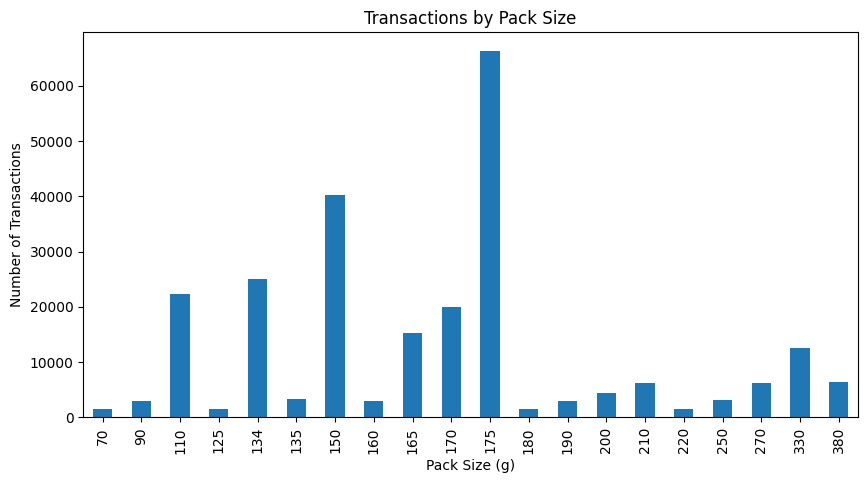

In [26]:
#packet size vs number of transactions
df_2['PACK_SIZE'].value_counts().sort_index().plot(kind='bar', figsize=(10,5))

plt.title('Transactions by Pack Size')
plt.xlabel('Pack Size (g)')
plt.ylabel('Number of Transactions')

plt.show()

In [27]:
# mid-sized packs are mostly prefered by customers (150-175g)

In [28]:
#create column for the price of product
df_2['PRICE'] = df_2['TOT_SALES'] / df_2['PROD_QTY']
df_2.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,BRAND,PACK_SIZE,PRICE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10,NCC,175,3.00
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05,CCs,175,2.10
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05,Smiths,170,1.45
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08,Smiths,175,3.00
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08,Kettle,150,4.60


In [29]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: ylabel='PROD_QTY'>

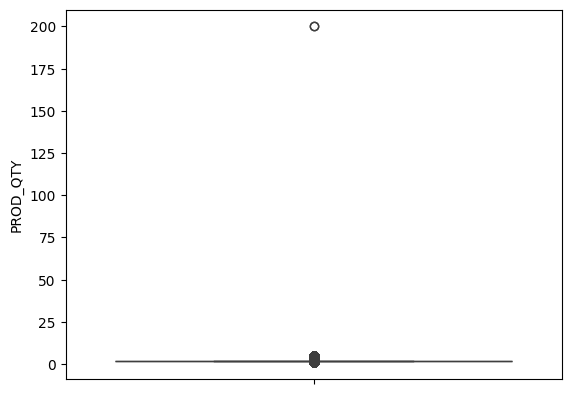

In [30]:
#find out outliers in the dataset
import seaborn as sns
sns.boxplot(data=df_2['PROD_QTY'])

In [31]:
#outlier
#same customer most likely a reseller
df_2[df_2['PROD_QTY'] > 100]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,BRAND,PACK_SIZE,PRICE
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,2018-08,Doritos,380,3.25
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,2019-05,Doritos,380,3.25


In [32]:
#combine two datasets for analysis
df_3 = pd.merge(df_2, df, on='LYLTY_CARD_NBR', how='left')
df_3.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,BRAND,PACK_SIZE,PRICE,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,2018-10,NCC,175,3.00,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,2019-05,CCs,175,2.10,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,2019-05,Smiths,170,1.45,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,2018-08,Smiths,175,3.00,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,2018-08,Kettle,150,4.60,MIDAGE SINGLES/COUPLES,Budget


In [33]:
df_3.shape

(246741, 14)

In [34]:
df_3.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
MONTH               0
BRAND               0
PACK_SIZE           0
PRICE               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [35]:
df_3[df_3['LYLTY_CARD_NBR']==226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,MONTH,BRAND,PACK_SIZE,PRICE,LIFESTAGE,PREMIUM_CUSTOMER
64955,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0,2018-08,Doritos,380,3.25,OLDER FAMILIES,Premium
64956,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0,2019-05,Doritos,380,3.25,OLDER FAMILIES,Premium


In [36]:
#since the outlier is a single customer. it was removed to gain general insight of the customers
df_4 = df_3[df_3['PROD_QTY'] < 100]

In [37]:
#which month of the year mostlikely to generate more revenue in chip sales
df_4.groupby('MONTH')['TOT_SALES'].sum().sort_values(ascending=False)

MONTH
2018-12    156461.60
2019-03    155772.80
2018-07    154514.50
2018-10    153448.10
2019-01    151593.80
2019-06    150135.90
2018-09    150058.90
2018-11    149609.50
2019-04    149374.20
2018-08    147422.05
2019-05    146300.35
2019-02    140480.00
Freq: M, Name: TOT_SALES, dtype: float64

In [38]:
#best perfomring store in chip sales
df_3.groupby('STORE_NBR')['TOT_SALES'].sum().sort_values(ascending=False)

STORE_NBR
226    17844.65
88     15445.85
165    15188.35
237    14830.60
40     14427.30
         ...   
92         9.20
206        7.60
252        7.40
11         6.70
76         6.00
Name: TOT_SALES, Length: 271, dtype: float64

In [39]:
#find out what customer segment generate more sales
df_4.groupby(['PREMIUM_CUSTOMER'])['TOT_SALES'].sum().sort_values(ascending=False)

PREMIUM_CUSTOMER
Mainstream    700865.40
Budget        631406.85
Premium       472899.45
Name: TOT_SALES, dtype: float64

In [40]:
#how many customers are in each segment
customer_counts = df_3.groupby(['PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].count()
customer_counts

PREMIUM_CUSTOMER
Budget        86762
Mainstream    95043
Premium       64936
Name: LYLTY_CARD_NBR, dtype: int64

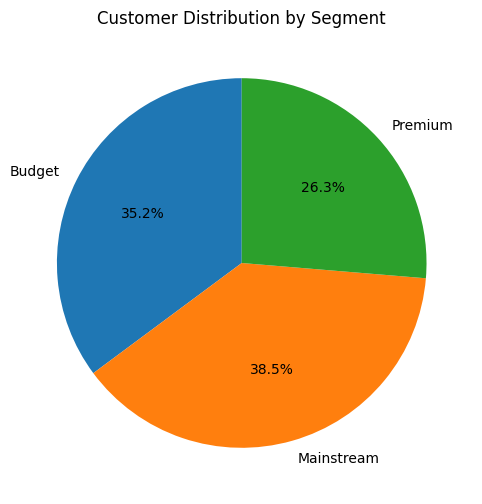

In [41]:
plt.figure(figsize=(6,6))

plt.pie(
    customer_counts,
    labels=customer_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Distribution by Segment')

plt.show()

In [42]:
#what life stage dominates each segment
lifestage_count = df_3.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE'])['LYLTY_CARD_NBR'].count().sort_index()
lifestage_count

PREMIUM_CUSTOMER  LIFESTAGE             
Budget            MIDAGE SINGLES/COUPLES     4691
                  NEW FAMILIES               2824
                  OLDER FAMILIES            21514
                  OLDER SINGLES/COUPLES     17172
                  RETIREES                  14225
                  YOUNG FAMILIES            17763
                  YOUNG SINGLES/COUPLES      8573
Mainstream        MIDAGE SINGLES/COUPLES    11095
                  NEW FAMILIES               2185
                  OLDER FAMILIES            13241
                  OLDER SINGLES/COUPLES     17061
                  RETIREES                  19970
                  YOUNG FAMILIES            11947
                  YOUNG SINGLES/COUPLES     19544
Premium           MIDAGE SINGLES/COUPLES     7612
                  NEW FAMILIES               1488
                  OLDER FAMILIES            10405
                  OLDER SINGLES/COUPLES     16559
                  RETIREES                  12236
         

In [43]:
#customers segment based on higest number of customers
lifestage_count.sort_values(ascending=False)

PREMIUM_CUSTOMER  LIFESTAGE             
Budget            OLDER FAMILIES            21514
Mainstream        RETIREES                  19970
                  YOUNG SINGLES/COUPLES     19544
Budget            YOUNG FAMILIES            17763
                  OLDER SINGLES/COUPLES     17172
Mainstream        OLDER SINGLES/COUPLES     17061
Premium           OLDER SINGLES/COUPLES     16559
Budget            RETIREES                  14225
Mainstream        OLDER FAMILIES            13241
Premium           RETIREES                  12236
Mainstream        YOUNG FAMILIES            11947
                  MIDAGE SINGLES/COUPLES    11095
Premium           YOUNG FAMILIES            10784
                  OLDER FAMILIES            10405
Budget            YOUNG SINGLES/COUPLES      8573
Premium           MIDAGE SINGLES/COUPLES     7612
                  YOUNG SINGLES/COUPLES      5852
Budget            MIDAGE SINGLES/COUPLES     4691
                  NEW FAMILIES               2824
Mainstrea

Text(0.5, 1.0, 'Budget Customers Composition')

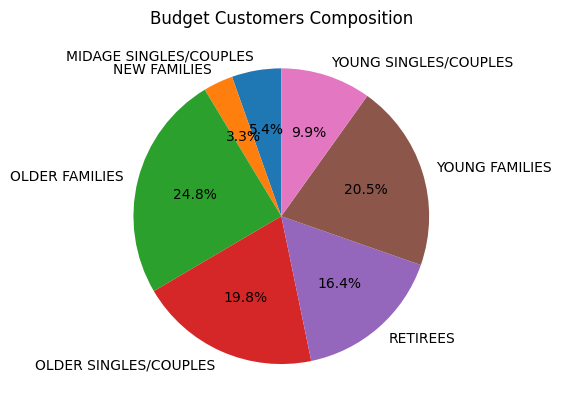

In [44]:
data = lifestage_count['Budget']
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
plt.title('Budget Customers Composition')

Text(0.5, 1.0, 'Mainstream Customers Composition')

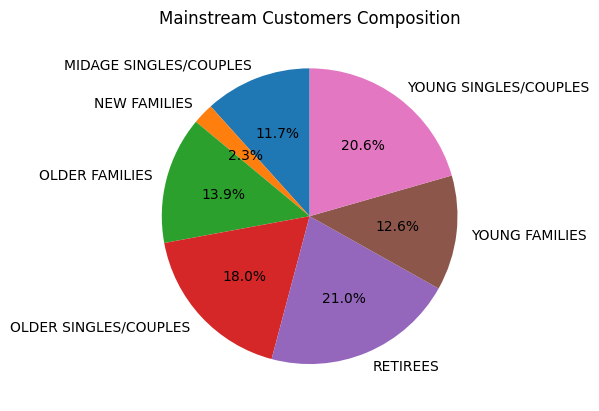

In [45]:
data = lifestage_count['Mainstream']
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
plt.title('Mainstream Customers Composition')

Text(0.5, 1.0, 'Premium Customers Composition')

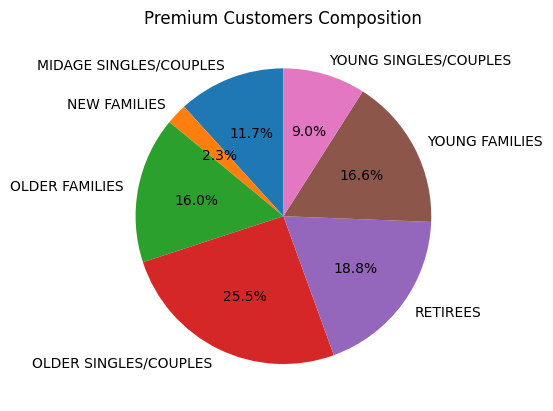

In [46]:
data = lifestage_count['Premium']
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
plt.title('Premium Customers Composition')

In [47]:
#how much each customer segment willing to pay for chips
df_3.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['PRICE'].mean()

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              3.743328
                        Mainstream          3.994241
                        Premium             3.770698
NEW FAMILIES            Budget              3.917688
                        Mainstream          3.916133
                        Premium             3.872110
OLDER FAMILIES          Budget              3.745340
                        Mainstream          3.737077
                        Premium             3.716910
OLDER SINGLES/COUPLES   Budget              3.882096
                        Mainstream          3.814665
                        Premium             3.893236
RETIREES                Budget              3.924404
                        Mainstream          3.844294
                        Premium             3.920942
YOUNG FAMILIES          Budget              3.760737
                        Mainstream          3.724533
                        Premium             3.762150
YOUNG

In [48]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
from scipy.stats import ttest_ind
#as per the data there's  no much avg price difference therefore a test is caried out to checvk
#t-test between mainstrem vs premium
mainstream = df_4[(df_4['PREMIUM_CUSTOMER'] == 'Mainstream') &
    (df_4['LIFESTAGE'].isin(['MIDAGE SINGLES/COUPLES', 'YOUNG SINGLES/COUPLES']))]
premium = df_4[(df_4['PREMIUM_CUSTOMER'].isin(['Premium', 'Budget'])) &
    (df_4['LIFESTAGE'].isin(['MIDAGE SINGLES/COUPLES', 'YOUNG SINGLES/COUPLES']))]
x = mainstream['PRICE'].dropna()
y = premium['PRICE'].dropna()
t_stat, p_value = ttest_ind(x, y, equal_var=False)
print("Mainstream avg price:", x.mean())
print("Premium avg price:", y.mean())
print("t-stat:", t_stat)
print("p-value:", p_value)

Mainstream avg price: 4.039785893795489
Premium avg price: 3.706491319964083
t-stat: 37.6243885962295
p-value: 6.967354233017819e-306


In [50]:
#as per the test the spending habbits aren't statistically different either

In [51]:
#find out what customer segment generate more sales
segment_sales = df_4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

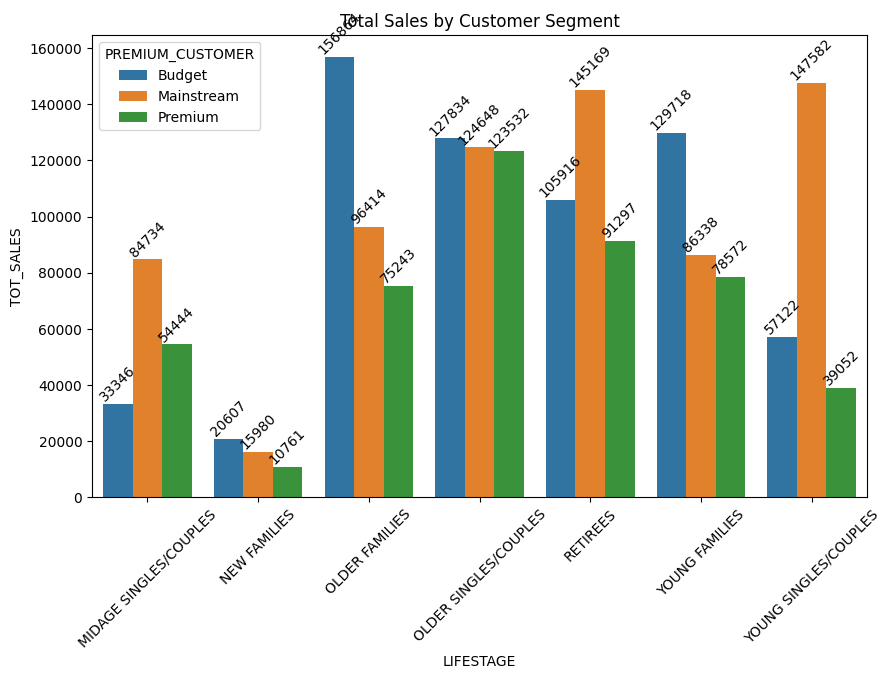

In [52]:
#plot the customer segment that generate most sales
plt.figure(figsize=(10,6))
sns.barplot(data=segment_sales, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title('Total Sales by Customer Segment')
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f', rotation=45)
plt.show()

In [53]:
#as we can see budget older families generate more sales, followed by mainstream young singles/couples and mainstream retirees

In [54]:
#find out what type customers buy most chips
df_4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum().sort_values(ascending=False)

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              41853
RETIREES                Mainstream          37677
YOUNG SINGLES/COUPLES   Mainstream          36225
YOUNG FAMILIES          Budget              34482
OLDER SINGLES/COUPLES   Budget              32883
                        Mainstream          32607
                        Premium             31693
RETIREES                Budget              26932
OLDER FAMILIES          Mainstream          25804
RETIREES                Premium             23266
YOUNG FAMILIES          Mainstream          23194
MIDAGE SINGLES/COUPLES  Mainstream          21213
YOUNG FAMILIES          Premium             20901
OLDER FAMILIES          Premium             20239
YOUNG SINGLES/COUPLES   Budget              15500
MIDAGE SINGLES/COUPLES  Premium             14400
YOUNG SINGLES/COUPLES   Premium             10575
MIDAGE SINGLES/COUPLES  Budget               8883
NEW FAMILIES            Budget               5241
         

In [55]:
#average spending per trx in each segment
df_4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].mean().sort_values(ascending=False)

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Mainstream          7.637156
YOUNG SINGLES/COUPLES   Mainstream          7.551279
RETIREES                Premium             7.461315
OLDER SINGLES/COUPLES   Premium             7.460085
RETIREES                Budget              7.445786
OLDER SINGLES/COUPLES   Budget              7.444305
NEW FAMILIES            Mainstream          7.313364
OLDER SINGLES/COUPLES   Mainstream          7.306049
YOUNG FAMILIES          Budget              7.302705
NEW FAMILIES            Budget              7.297256
OLDER FAMILIES          Budget              7.291241
YOUNG FAMILIES          Premium             7.285951
OLDER FAMILIES          Mainstream          7.281440
RETIREES                Mainstream          7.269352
OLDER FAMILIES          Premium             7.232779
NEW FAMILIES            Premium             7.231720
YOUNG FAMILIES          Mainstream          7.226772
MIDAGE SINGLES/COUPLES  Premium             7.152371
     

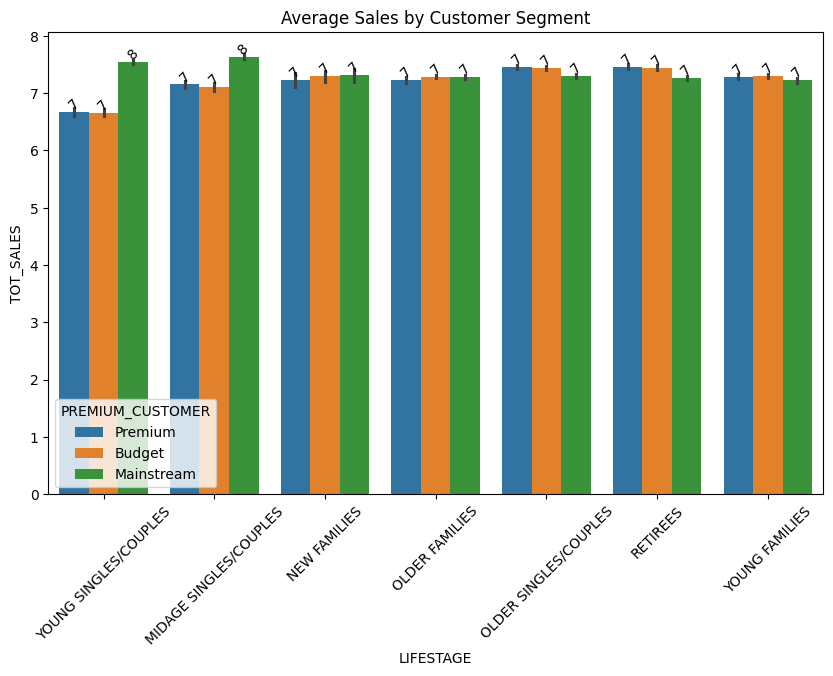

In [56]:
#visualise the salse behaviour
plt.figure(figsize=(10,6))
sns.barplot(data= df_4, x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER')
plt.xticks(rotation=45)
plt.title('Average Sales by Customer Segment')
for container in plt.gca().containers:
    plt.bar_label(container, fmt= '%.0f', rotation=45)
plt.show()

In [57]:
#As we can see young single/couples and middleaged single/couples in mainstreem category tend to spend more per chip purchase

In [58]:
#most revenue generating chip
df_4.groupby('PROD_NAME')['TOT_SALES'].sum().sort_values(ascending=False)

PROD_NAME
Dorito Corn Chp     Supreme 380g            39052.0
Smiths Crnkle Chip  Orgnl Big Bag 380g      36367.6
Smiths Crinkle Chips Salt & Vinegar 330g    34804.2
Kettle Mozzarella   Basil & Pesto 175g      34457.4
Smiths Crinkle      Original 330g           34302.6
                                             ...   
Woolworths Cheese   Rings 190g               5169.6
Snbts Whlgrn Crisps Cheddr&Mstrd 90g         5076.2
WW Crinkle Cut      Chicken 175g             4702.2
Sunbites Whlegrn    Crisps Frch/Onin 90g     4600.2
WW Crinkle Cut      Original 175g            4532.2
Name: TOT_SALES, Length: 105, dtype: float64

In [59]:
#the most selling 
df_4.groupby('PROD_NAME')['PROD_QTY'].sum().sort_values(ascending=False)

PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      6381
Kettle Tortilla ChpsHny&Jlpno Chili 150g    6309
Cobs Popd Sea Salt  Chips 110g              6277
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    6256
Tostitos Splash Of  Lime 175g               6234
                                            ... 
Sunbites Whlegrn    Crisps Frch/Onin 90g    2706
RRD Pc Sea Salt     165g                    2702
NCC Sour Cream &    Garden Chives 175g      2682
WW Crinkle Cut      Original 175g           2666
French Fries Potato Chips 175g              2643
Name: PROD_QTY, Length: 105, dtype: int64

In [60]:
#most loyal customers and the store they visit for  chips
df_3.groupby(['LYLTY_CARD_NBR', 'PREMIUM_CUSTOMER', 'LIFESTAGE', 'STORE_NBR'])['TXN_ID'].count().sort_values(ascending=False)

LYLTY_CARD_NBR  PREMIUM_CUSTOMER  LIFESTAGE              STORE_NBR
162039          Mainstream        OLDER FAMILIES         162          17
230078          Budget            OLDER FAMILIES         230          17
23192           Budget            OLDER FAMILIES         23           16
105026          Budget            YOUNG FAMILIES         105          16
179228          Budget            YOUNG FAMILIES         179          16
                                                                      ..
2330321         Mainstream        YOUNG SINGLES/COUPLES  77            1
2330331         Budget            RETIREES               77            1
861921          Premium           OLDER SINGLES/COUPLES  155           1
861951          Budget            RETIREES               155           1
861961          Budget            YOUNG FAMILIES         155           1
Name: TXN_ID, Length: 71289, dtype: int64

In [61]:
#basket size or number of items per purchase (without the outlier of 200 bags of chips)
df_4.groupby('TXN_ID')['PROD_QTY'].sum().describe()

count    245255.000000
mean          1.917991
std           0.377388
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           6.000000
Name: PROD_QTY, dtype: float64

In [62]:
#most popular chip amoung each customer segment
top_chip_full_segment = (
    df_4.groupby(['LIFESTAGE','PREMIUM_CUSTOMER','PROD_NAME'])['PROD_QTY']
    .sum()
    .reset_index()
    .sort_values(
        ['LIFESTAGE', 'PREMIUM_CUSTOMER', 'PROD_QTY'],
        ascending=[True, True, False]
    )
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .head(1)
)

top_chip_full_segment

,LIFESTAGE,PREMIUM_CUSTOMER,PROD_NAME,PROD_QTY
27,MIDAGE SINGLES/COUPLES,Budget,Infzns Crn Crnchers Tangy Gcamole 110g,147
176,MIDAGE SINGLES/COUPLES,Mainstream,Smiths Crinkle Chips Salt & Vinegar 330g,369
263,MIDAGE SINGLES/COUPLES,Premium,Pringles Sweet&Spcy BBQ 134g,221
345,NEW FAMILIES,Budget,Kettle Honey Soy Chicken 175g,95
438,NEW FAMILIES,Mainstream,Doritos Mexicana 170g,74
545,NEW FAMILIES,Premium,Grain Waves Sweet Chilli 210g,59
661,OLDER FAMILIES,Budget,Kettle Mozzarella Basil & Pesto 175g,561
744,OLDER FAMILIES,Mainstream,Cobs Popd Sour Crm &Chives Chips 110g,352
887,OLDER FAMILIES,Premium,Pringles Chicken Salt Crips 134g,290
953,OLDER SINGLES/COUPLES,Budget,Cobs Popd Sea Salt Chips 110g,494


In [63]:
#chip brand preference by each customer segement
brand = (
    df_4.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE', 'BRAND'])['PROD_QTY'].sum()
        .reset_index()
        .sort_values(['PREMIUM_CUSTOMER', 'PROD_QTY'], ascending=[True, False])
        .groupby('PREMIUM_CUSTOMER').head(3)
)
brand

,PREMIUM_CUSTOMER,LIFESTAGE,BRAND,PROD_QTY
49,Budget,OLDER FAMILIES,Kettle,6492
69,Budget,OLDER SINGLES/COUPLES,Kettle,5896
53,Budget,OLDER FAMILIES,Smiths,5717
269,Mainstream,YOUNG SINGLES/COUPLES,Kettle,7172
229,Mainstream,RETIREES,Kettle,6428
209,Mainstream,OLDER SINGLES/COUPLES,Kettle,5462
349,Premium,OLDER SINGLES/COUPLES,Kettle,5666
369,Premium,RETIREES,Kettle,4230
353,Premium,OLDER SINGLES/COUPLES,Smiths,3719


In [64]:
# What stores do each customer segment mostly interact with
shop = (
    df_3.groupby(['PREMIUM_CUSTOMER', 'STORE_NBR'])['TXN_ID'].count()
        .reset_index(name='VISITS')\
        .sort_values(['PREMIUM_CUSTOMER', 'VISITS'], ascending=[True, False])
        .groupby('PREMIUM_CUSTOMER').head(3)
)
shop

,PREMIUM_CUSTOMER,STORE_NBR,VISITS
221,Budget,226,714
90,Budget,93,712
208,Budget,213,675
489,Mainstream,226,749
501,Mainstream,238,703
270,Mainstream,4,693
696,Premium,165,566
631,Premium,100,522
620,Premium,88,509
